In [1]:
%load_ext autoreload
%autoreload 2

from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import matplotlib as mpl

from tqdm.auto import tqdm

import warnings
warnings.simplefilter(action='ignore', category=pd.errors.PerformanceWarning)

from multiprocess import Pool

from scipy import stats

workspace_root = os.getcwd()
sys.path.insert(0, workspace_root + "/../../../../")
import pyanalib.pandas_helpers as ph
import pyanalib.split_df_helpers as sh
from makedf.util import *

sys.path.insert(0, workspace_root + "/../../")
import kinematics
import gump_cuts as gc
import loaddf
import syst
import importlib

In [2]:
DETECTOR = "SBND"
INCLUDE_DIRT=True
FONTSIZE = 14
DF_DIR = "/exp/sbnd/data/users/gputnam/GUMP/sbn-rewgted-7/"

In [3]:
if DETECTOR == "ICARUS Run2":
    ONBEAM = DF_DIR.replace('7', '6') + "ICARUS_SpringRun2BNB_unblind_prescaled.df"
    OFFBEAM = [DF_DIR + "ICARUS_SpringRun2BNBOff_unblind_prescaled.df"]
    
    ONBEAMPOT = DF_DIR + "ICARUS_SpringRun2BNB_unblind_prescaled_POT.df"

    MC_FILES = [DF_DIR + "ICARUS_SpringMCOverlay_rewgt.df"]

    DIRT_FILE = DF_DIR + "ICARUS_Spring_Overlay_Dirt.df"
    
    DETVAR_FILES = []
    DETVAR_NAMES = []
elif DETECTOR == "ICARUS Run4":
    ONBEAM = DF_DIR + "ICARUS_SpringRun4BNB_unblind_prescaled.df"
    #OFFBEAM = [DF_DIR.replace('7', '6').replace('gputnam', 'nrowe') + "ICARUSRun4_BNBoff_%i.df" % i for i in range(60)]
    OFFBEAM = [DF_DIR.replace('7', '6') + "ICARUS_SpringRun4BNBOff_unblind_prescaled.df"]
    
    ONBEAMPOT = DF_DIR + "ICARUS_SpringRun4BNB_unblind_prescaled_POT.df"

    MC_FILES = [DF_DIR + "ICARUSRun4_SpringMCOverlay_rewgt_%i.df" % i for i in range(10)]

    DIRT_FILE = DF_DIR + "ICARUSRun4_Spring_Overlay_Dirt_lowE.df"
    
    DETVAR_FILES = []
    DETVAR_NAMES = []
elif DETECTOR == "SBND": 
    ONBEAM = DF_DIR + "SBND_SpringBNBData_FixedDev.df"
    OFFBEAM = DF_DIR + "SBND_SpringBNBOffData_5000.df"
    
    MC_FILES = [DF_DIR + "SBND_SpringMC_rewgt_E_%i.df" % i for i in range(20)]
    DIRT_FILE = DF_DIR + "SBND_SpringLowEMC.df"

    DETVAR_FILES = [DF_DIR + "SBND_SpringMC_Nom.df", DF_DIR + "SBND_SpringMC_WMXThetaXW.df", DF_DIR + "SBND_SpringMC_WMYZ.df", DF_DIR + "SBND_SpringMC_2xSCE.df"]
    DETVAR_NAMES = ["Nominal", "WMXThetaXW", "WMYZ", "2xSCE"]

In [4]:
if "ICARUS" in DETECTOR:
    if "Run4" in DETECTOR:
        P = 40
    elif "Run2" in DETECTOR:
        P = 200
    ngates_ON = sh.load_dfs(ONBEAM, ["trig"])['trig'].gate_delta.sum()*(1-1/P)
    ngates_OFF = sum([sh.load_dfs(O, ["trig"])['trig'].gate_delta.sum()*(1-1/20) for O in OFFBEAM])
    
    OFF_w = ngates_ON / ngates_OFF
elif "SBND" in DETECTOR:
    ngates_ON = sh.load_dfs(ONBEAM, ["bnb"])['bnb'].shape[0]
    ngates_OFF = sh.load_dfs(OFFBEAM, ["hdr"])['hdr'].noffbeambnb.sum()

    f_factor = 0.0754 # fraction of gates triggered by a neutrino from SBN-doc-41013-v4
    OFF_w = (1. - f_factor) * (ngates_ON) / (ngates_OFF)

if "ICARUS" in DETECTOR:
    # POT = pd.read_hdf(ONBEAMPOT).pot.sum()*1e12
    POT = sh.load_dfs(ONBEAM, ["hdr"])['hdr'].merge(pd.read_hdf(ONBEAMPOT), left_index=True, right_index=True, how="left").pot_y.sum()*1e12
elif "SBND" in DETECTOR:
    POT = sh.load_dfs(ONBEAM, ["bnb"])['bnb'].TOR875.sum()

In [5]:
# LOAD MC CV SAMPLES
ncores=20
df, match, mcpot = loaddf.loadl(MC_FILES, njob=min(len(MC_FILES), ncores), include_syst=True, reweight_aFF=True, preselection=gc.presel_cut, detector=DETECTOR, drops=loaddf.get_std_drops(), progress=False, lightmem=True)
loaddf.scale_pot(df, mcpot, POT)

# LOAD DETECTOR VARIATION SAMPLES
if len(DETVAR_FILES) > 0:
    detvars, detvars_match, detvar_pots = zip(*[loaddf.load(f, include_syst=False, detector=DETECTOR, lightmem=True, drops=loaddf.get_std_drops()) for f in tqdm(DETVAR_FILES)])
    detvars, detvar_pots = loaddf.match_common_evts(detvars_match, detvars, detvar_pots)
else:
    detvars = []
    detvar_pots = []

for i in range(len(detvars)):
    print(DETVAR_NAMES[i])
    loaddf.scale_pot(detvars[i], detvar_pots[i], POT)

/exp/sbnd/app/users/nrowe/cafpyana/analysis_village/gump/nb/N8nb/../../gump_cuts.py:469: RuntimeWarning: invalid value encountered in subtract
  direction = p2 - p1
/exp/sbnd/app/users/nrowe/cafpyana/analysis_village/gump/nb/N8nb/../../gump_cuts.py:469: RuntimeWarning: invalid value encountered in subtract
  direction = p2 - p1
/exp/sbnd/app/users/nrowe/cafpyana/analysis_village/gump/nb/N8nb/../../gump_cuts.py:484: RuntimeWarning: invalid value encountered in subtract
  tmin = (p_min[i] - p1[:, i]) * inv_dir
/exp/sbnd/app/users/nrowe/cafpyana/analysis_village/gump/nb/N8nb/../../gump_cuts.py:485: RuntimeWarning: invalid value encountered in subtract
  tmax = (p_max[i] - p1[:, i]) * inv_dir
/exp/sbnd/app/users/nrowe/cafpyana/analysis_village/gump/nb/N8nb/../../gump_cuts.py:469: RuntimeWarning: invalid value encountered in subtract
  direction = p2 - p1
/exp/sbnd/app/users/nrowe/cafpyana/analysis_village/gump/nb/N8nb/../../gump_cuts.py:484: RuntimeWarning: invalid value encountered in sub

[SBND_SpringMC_rewgt_E_10.df idf=0] dedup: dropped 0 duplicated ('run', 'evt', 'nu_E0') keys (0 hdr rows)
[SBND_SpringMC_rewgt_E_16.df idf=0] dedup: dropped 0 duplicated ('run', 'evt', 'nu_E0') keys (0 hdr rows)


/exp/sbnd/app/users/nrowe/cafpyana/analysis_village/gump/nb/N8nb/../../gump_cuts.py:469: RuntimeWarning: invalid value encountered in subtract
  direction = p2 - p1


[SBND_SpringMC_rewgt_E_11.df idf=0] dedup: dropped 0 duplicated ('run', 'evt', 'nu_E0') keys (0 hdr rows)


/exp/sbnd/app/users/nrowe/cafpyana/analysis_village/gump/nb/N8nb/../../gump_cuts.py:469: RuntimeWarning: invalid value encountered in subtract
  direction = p2 - p1
/exp/sbnd/app/users/nrowe/cafpyana/analysis_village/gump/nb/N8nb/../../gump_cuts.py:484: RuntimeWarning: invalid value encountered in subtract
  tmin = (p_min[i] - p1[:, i]) * inv_dir
/exp/sbnd/app/users/nrowe/cafpyana/analysis_village/gump/nb/N8nb/../../gump_cuts.py:485: RuntimeWarning: invalid value encountered in subtract
  tmax = (p_max[i] - p1[:, i]) * inv_dir
/exp/sbnd/app/users/nrowe/cafpyana/analysis_village/gump/nb/N8nb/../../gump_cuts.py:469: RuntimeWarning: invalid value encountered in subtract
  direction = p2 - p1
/exp/sbnd/app/users/nrowe/cafpyana/analysis_village/gump/nb/N8nb/../../gump_cuts.py:484: RuntimeWarning: invalid value encountered in subtract
  tmin = (p_min[i] - p1[:, i]) * inv_dir
/exp/sbnd/app/users/nrowe/cafpyana/analysis_village/gump/nb/N8nb/../../gump_cuts.py:485: RuntimeWarning: invalid value

...

(np.float32(1.05469105e+20), np.float32(0.044367176))

WMYZ
0.044367112


(np.float32(1.0546926e+20), np.float32(0.044367112))

2xSCE
0.04440443


(np.float32(1.05380625e+20), np.float32(0.04440443))

In [6]:
# This removes things in the AV, so that our dirt sample is actually a dirt sample
if INCLUDE_DIRT and DIRT_FILE is not None:
    dirt, dirtmatch, dirtpot = loaddf.load(DIRT_FILE, include_syst=False, preselection=gc.presel_cut, detector=DETECTOR, lightmem=True, drops=loaddf.get_std_drops())
    loaddf.scale_pot(dirt, dirtpot, POT)
    
    if DETECTOR == "ICARUS":
        dirt = dirt[gc.ICARUS_dirtcut(dirt)]

    dirt["crthit"] = False
    dirt["dirt"] = True
    df["dirt"] = False
    for i in range(len(detvars)):
        detvars[i] = pd.concat([detvars[i], dirt])
elif INCLUDE_DIRT:
    df["dirt"] = False

/exp/sbnd/app/users/nrowe/cafpyana/analysis_village/gump/nb/N8nb/../../gump_cuts.py:469: RuntimeWarning: invalid value encountered in subtract
  direction = p2 - p1
/exp/sbnd/app/users/nrowe/cafpyana/analysis_village/gump/nb/N8nb/../../gump_cuts.py:484: RuntimeWarning: invalid value encountered in subtract
  tmin = (p_min[i] - p1[:, i]) * inv_dir
/exp/sbnd/app/users/nrowe/cafpyana/analysis_village/gump/nb/N8nb/../../gump_cuts.py:485: RuntimeWarning: invalid value encountered in subtract
  tmax = (p_max[i] - p1[:, i]) * inv_dir


[SBND_SpringLowEMC.df idf=0] dedup: dropped 3 duplicated ('run', 'evt', 'nu_E0') keys (6 hdr rows)


/exp/sbnd/app/users/nrowe/cafpyana/analysis_village/gump/nb/N8nb/../../gump_cuts.py:469: RuntimeWarning: invalid value encountered in subtract
  direction = p2 - p1
/exp/sbnd/app/users/nrowe/cafpyana/analysis_village/gump/nb/N8nb/../../gump_cuts.py:484: RuntimeWarning: invalid value encountered in subtract
  tmin = (p_min[i] - p1[:, i]) * inv_dir
/exp/sbnd/app/users/nrowe/cafpyana/analysis_village/gump/nb/N8nb/../../gump_cuts.py:485: RuntimeWarning: invalid value encountered in subtract
  tmax = (p_max[i] - p1[:, i]) * inv_dir


[SBND_SpringLowEMC.df idf=1] dedup: dropped 1 duplicated ('run', 'evt', 'nu_E0') keys (2 hdr rows)


/exp/sbnd/app/users/nrowe/cafpyana/analysis_village/gump/nb/N8nb/../../gump_cuts.py:469: RuntimeWarning: invalid value encountered in subtract
  direction = p2 - p1
/exp/sbnd/app/users/nrowe/cafpyana/analysis_village/gump/nb/N8nb/../../gump_cuts.py:484: RuntimeWarning: invalid value encountered in subtract
  tmin = (p_min[i] - p1[:, i]) * inv_dir
/exp/sbnd/app/users/nrowe/cafpyana/analysis_village/gump/nb/N8nb/../../gump_cuts.py:485: RuntimeWarning: invalid value encountered in subtract
  tmax = (p_max[i] - p1[:, i]) * inv_dir


...

/exp/sbnd/app/users/nrowe/cafpyana/analysis_village/gump/nb/N8nb/../../gump_cuts.py:469: RuntimeWarning: invalid value encountered in subtract
  direction = p2 - p1
/exp/sbnd/app/users/nrowe/cafpyana/analysis_village/gump/nb/N8nb/../../gump_cuts.py:484: RuntimeWarning: invalid value encountered in subtract
  tmin = (p_min[i] - p1[:, i]) * inv_dir
/exp/sbnd/app/users/nrowe/cafpyana/analysis_village/gump/nb/N8nb/../../gump_cuts.py:485: RuntimeWarning: invalid value encountered in subtract
  tmax = (p_max[i] - p1[:, i]) * inv_dir


[SBND_SpringLowEMC.df idf=3] dedup: dropped 0 duplicated ('run', 'evt', 'nu_E0') keys (0 hdr rows)


/exp/sbnd/app/users/nrowe/cafpyana/analysis_village/gump/nb/N8nb/../../gump_cuts.py:469: RuntimeWarning: invalid value encountered in subtract
  direction = p2 - p1
/exp/sbnd/app/users/nrowe/cafpyana/analysis_village/gump/nb/N8nb/../../gump_cuts.py:484: RuntimeWarning: invalid value encountered in subtract
  tmin = (p_min[i] - p1[:, i]) * inv_dir
/exp/sbnd/app/users/nrowe/cafpyana/analysis_village/gump/nb/N8nb/../../gump_cuts.py:485: RuntimeWarning: invalid value encountered in subtract
  tmax = (p_max[i] - p1[:, i]) * inv_dir


[SBND_SpringLowEMC.df idf=4] dedup: dropped 0 duplicated ('run', 'evt', 'nu_E0') keys (0 hdr rows)
[SBND_SpringLowEMC.df] cross-idf dedup: dropped 23 duplicated ('run', 'evt', 'nu_E0') keys (46 match rows)
0.025910718


(np.float32(1.8059579e+20), np.float32(0.025910718))

In [7]:
if INCLUDE_DIRT and DIRT_FILE is not None:
    # reset df if needed
    df.query("dirt == False", inplace=True)
    # add dirt to the CV, and also include it (below) as a 100 syst unc.
    df = pd.concat([df, dirt])
    # keep copy of non-dirt around for chi2 systematic variation CV
    df0 = df.loc[~df.dirt, [c for c in df.columns if "univ" not in c]]
    
    # disable systematic weights associated with dirt events
    for c in df.columns:
        if "univ" in c:
            df[c] = df[c].fillna(1)
            
elif INCLUDE_DIRT:
    # keep copy of non-dirt around for chi2 systematic variation CV
    df0 = df.loc[~df.dirt, [c for c in df.columns if "univ" not in c]]
del dirt

df0 = df0.drop(columns=[col for col in df0.columns if 'univ' in col])

chi2_detvars = [[syst.v_chi2hi(df0), syst.v_chi2lo(df0)], syst.v_chi2smear(df0)]

df_ooav = df[gc.OOAV(df)].copy()

In [8]:
ONdf,_,_ = loaddf.load(ONBEAM, load_truth=False, include_syst=False, detector=DETECTOR, preselection=gc.presel_cut, match_Enu=False, drops=loaddf.get_std_drops(), lightmem=True)
if "ICARUS" in DETECTOR:
    OFFdf,_,OFFpot = loaddf.loadl(OFFBEAM, load_truth=False, include_syst=False, detector=DETECTOR, preselection=gc.presel_cut, match_Enu=False, drops=loaddf.get_std_drops(), lightmem=True, offbeampot=True)
else:
    OFFdf,_,OFFpot = loaddf.load(OFFBEAM, load_truth=False, include_syst=False, detector=DETECTOR, preselection=gc.presel_cut, match_Enu=False, drops=loaddf.get_std_drops(), lightmem=True, offbeampot=True)

/exp/sbnd/app/users/nrowe/cafpyana/analysis_village/gump/nb/N8nb/../../gump_cuts.py:469: RuntimeWarning: invalid value encountered in subtract
  direction = p2 - p1
/exp/sbnd/app/users/nrowe/cafpyana/analysis_village/gump/nb/N8nb/../../gump_cuts.py:484: RuntimeWarning: invalid value encountered in subtract
  tmin = (p_min[i] - p1[:, i]) * inv_dir
/exp/sbnd/app/users/nrowe/cafpyana/analysis_village/gump/nb/N8nb/../../gump_cuts.py:485: RuntimeWarning: invalid value encountered in subtract
  tmax = (p_max[i] - p1[:, i]) * inv_dir


[SBND_SpringBNBData_FixedDev.df idf=0] dedup: dropped 1850 duplicated ('run', 'evt') keys (3700 hdr rows)


/exp/sbnd/app/users/nrowe/cafpyana/analysis_village/gump/nb/N8nb/../../gump_cuts.py:469: RuntimeWarning: invalid value encountered in subtract
  direction = p2 - p1
/exp/sbnd/app/users/nrowe/cafpyana/analysis_village/gump/nb/N8nb/../../gump_cuts.py:484: RuntimeWarning: invalid value encountered in subtract
  tmin = (p_min[i] - p1[:, i]) * inv_dir
/exp/sbnd/app/users/nrowe/cafpyana/analysis_village/gump/nb/N8nb/../../gump_cuts.py:485: RuntimeWarning: invalid value encountered in subtract
  tmax = (p_max[i] - p1[:, i]) * inv_dir


[SBND_SpringBNBOffData_5000.df idf=0] dedup: dropped 5179 duplicated ('run', 'evt') keys (10458 hdr rows)


/exp/sbnd/app/users/nrowe/cafpyana/analysis_village/gump/nb/N8nb/../../gump_cuts.py:469: RuntimeWarning: invalid value encountered in subtract
  direction = p2 - p1
/exp/sbnd/app/users/nrowe/cafpyana/analysis_village/gump/nb/N8nb/../../gump_cuts.py:484: RuntimeWarning: invalid value encountered in subtract
  tmin = (p_min[i] - p1[:, i]) * inv_dir
/exp/sbnd/app/users/nrowe/cafpyana/analysis_village/gump/nb/N8nb/../../gump_cuts.py:485: RuntimeWarning: invalid value encountered in subtract
  tmax = (p_max[i] - p1[:, i]) * inv_dir


[SBND_SpringBNBOffData_5000.df idf=1] dedup: dropped 946 duplicated ('run', 'evt') keys (1892 hdr rows)
[SBND_SpringBNBOffData_5000.df] cross-idf dedup: dropped 4050 duplicated ('run', 'evt') keys (8100 match rows)


In [9]:
def f_chi2(NMC, Ndata, cov):
    # ignore singular entries
    which_bin = NMC > 0

    NMC = NMC[which_bin]
    Ndata = Ndata[which_bin]
    cov = cov[which_bin, :]
    cov = cov[:, which_bin]

    delta = NMC - Ndata
    try:
        cov_inv = np.linalg.inv(cov)
    except np.linalg.LinAlgError as _:
        return -1, which_bin.sum()
        
    return delta@cov_inv@delta, which_bin.sum()

In [10]:
extravarnames = [
    "mu_costh",
    "mu_phi",
    "p_costh",
    "p_phi",
]

extravars = [
    lambda d: np.cos(d.mu_dir_z),
    lambda d: np.arctan2(d.mu_dir_x, d.mu_dir_y)*180/np.pi,
    lambda d: np.cos(d.p_dir_z),
    lambda d: np.arctan2(d.p_dir_x, d.p_dir_y)*180/np.pi,
]

In [11]:
for v, vname in zip(extravars, extravarnames):
    df[vname] = v(df)
    df0[vname] = v(df0)
    df_ooav[vname] = v(df_ooav)
    ONdf[vname] = v(ONdf)
    OFFdf[vname] = v(OFFdf)

    #if INCLUDE_DIRT and DIRT_FILE is not None:
    #    dirt[vname] = v(dirt)

    for i in range(len(detvars)):
        detvars[i][vname] = v(detvars[i])

    for i in range(len(chi2_detvars)):
        if isinstance(chi2_detvars[i], list):
            for j in range(len(chi2_detvars[i])):
                chi2_detvars[i][j][vname] = v(chi2_detvars[i][j])
        else:
            chi2_detvars[i][vname] = v(chi2_detvars[i])

In [12]:
def step_0(df):
    return gc.presel_cut(df)

def step_1(df):
    return step_0(df) & gc.cosmic_cut(df)

def step_2(df):
    return step_1(df) & gc.flash_cut(df)
    
def step_3(df):
    return step_2(df) & gc.twoprong_cut(df)

def step_4(df):
    return step_3(df) & gc.pid_cut(df)

In [13]:
CONFERENCE = False
dbd = False

if dbd:
    PLOTDIR = "/exp/sbnd/app/users/nrowe/cafpyana/analysis_village/gump/nb/Neutrino26Plots/"
elif CONFERENCE:
    PLOTDIR = "/exp/sbnd/app/users/nrowe/cafpyana/analysis_village/gump/nb/Neutrino26PlotsWhite/"
elif not CONFERENCE:
    PLOTDIR = "/exp/sbnd/app/users/nrowe/cafpyana/analysis_village/gump/nb/SBNDCM26Plots/"

os.makedirs(PLOTDIR, exist_ok=True)
os.makedirs(PLOTDIR + "/png", exist_ok=True)

In [14]:
if DETECTOR == "SBND":
    x_range = np.linspace(-200, 200, 21)
    y_range = np.linspace(-200, 200, 21)
    z_range = np.linspace(0, 500, 21)
else:
    x_range = np.linspace(-360, 360, 21)
    y_range = np.linspace(-182, 135, 21)
    z_range = np.linspace(-895, 895, 21)

cuts = [
    step_0,
    step_1,
    step_2,
    step_3,
    step_4,
    step_4,
]

cutnames = [
    "Per TPC Contained",
    "Cosmic Cut",
    "Flash Cut",
    "Two Prong Cut",
    "PID Cut",
    r"1$\mu$1p Selection"
]

plotvars = [
    [],
    ["mu_p_opening_angle_deg", "nu_score"],
    ["flash_maxpe"],
    ["other_trk_length", "other_shw_length"],
    ["mu_chi2_of_prot_cand", "prot_chi2_of_prot_cand", "mu_chi2_of_mu_cand", "prot_chi2_of_mu_cand", "mu_len"],
    ["del_p"]
]

labels = [
    [],
    ["Muon-Proton Opening Angle [degrees]", "$\\nu$ Score"],
    ["Max In-Time Flash Total PE"],
    ["Maximum Third Track Length [cm]", "Maximum Shower Length [cm]"],
    ["Proton Cand. $\\mu$-like PID", "Proton Cand. $p$-like PID", "Muon Cand. $\\mu$-like PID", "Muon Cand. $p$-like PID", "Muon Cand. Length [cm]"],
    ["$\\delta p$ [GeV]"]
]

bins = [
    [],
    [np.linspace(0., 180., 11), np.linspace(0.25, 0.75, 11)],
    [np.linspace(0, 40000, 20)],
    [np.array([-5] + list(np.linspace(0, 20, 5))), np.array([-10] + list(np.linspace(0, 100, 11)))],
    [np.linspace(0, 60, 13), np.linspace(0, 120, 9), np.linspace(0, 60, 13), np.linspace(0, 300, 21), np.linspace(0, 100, 21)],
    [np.linspace(0., 1., 21)]
]


In [15]:
for c, cname in zip(cuts, cutnames):
    df[cname] = c(df)
    df0[cname] = c(df0)
    df_ooav[cname] = c(df_ooav)
    ONdf[cname] = c(ONdf)
    OFFdf[cname] = c(OFFdf)

    for i in range(len(detvars)):
        detvars[i][cname] = c(detvars[i])
        
    for i in range(len(chi2_detvars)):
        if isinstance(chi2_detvars[i], list):
            for j in range(len(chi2_detvars[i])):
                chi2_detvars[i][j][cname] = c(chi2_detvars[i][j])
        else:
            chi2_detvars[i][cname] = c(chi2_detvars[i])

/exp/sbnd/app/users/nrowe/cafpyana/analysis_village/gump/nb/N8nb/../../gump_cuts.py:469: RuntimeWarning: invalid value encountered in subtract
  direction = p2 - p1
/exp/sbnd/app/users/nrowe/cafpyana/analysis_village/gump/nb/N8nb/../../gump_cuts.py:484: RuntimeWarning: invalid value encountered in subtract
  tmin = (p_min[i] - p1[:, i]) * inv_dir
/exp/sbnd/app/users/nrowe/cafpyana/analysis_village/gump/nb/N8nb/../../gump_cuts.py:485: RuntimeWarning: invalid value encountered in subtract
  tmax = (p_max[i] - p1[:, i]) * inv_dir
/exp/sbnd/app/users/nrowe/cafpyana/analysis_village/gump/nb/N8nb/../../gump_cuts.py:469: RuntimeWarning: invalid value encountered in subtract
  direction = p2 - p1
/exp/sbnd/app/users/nrowe/cafpyana/analysis_village/gump/nb/N8nb/../../gump_cuts.py:484: RuntimeWarning: invalid value encountered in subtract
  tmin = (p_min[i] - p1[:, i]) * inv_dir
/exp/sbnd/app/users/nrowe/cafpyana/analysis_village/gump/nb/N8nb/../../gump_cuts.py:485: RuntimeWarning: invalid value

In [16]:
if DETECTOR == "SBND":
    systematics = [
        loaddf.FluxSystematic(df),
        loaddf.XSecSystematic(df),
        syst.NormalizationSystematic(0.005),
        syst.SystSampleSystematic(df[gc.OOAVSBND(df)]),
        #syst.SampleSystematic(OFFdf, norm=0.1)
        #syst.StatSampleSystematic(Soffbeam, norm=0.1) # TODO: change after unblinding. Simulate scaling up stats by 10x.
    ]
elif "ICARUS" in DETECTOR:
    systematics = [
        loaddf.FluxSystematic(df),
        loaddf.XSecSystematic(df),
        syst.NormalizationSystematic(0.005),
        syst.SystSampleSystematic(df[gc.OOAVICARUS(df)]),
        #syst.SampleSystematic(OFFdf, norm=0.1) 
        #syst.StatSampleSystematic(Ioffbeam, norm=0.1) # TODO: change after unblinding. Simulate scaling up stats by 10x.
    ]

if CONFERENCE==False:
    if "ICARUS" in DETECTOR:
        syst_det = syst.SystematicList([syst.SampleSystematic(d) for d in chi2_detvars]+\
                                        [syst.SystSampleSystematic(df[gc.OOAVICARUS(df)])]
                                       )
    elif DETECTOR == "SBND":
        syst_det = syst.SystematicList([syst.SampleSystematic(d, cvdf=detvars[0]) for d in detvars[1:]]+\
                                        [syst.SampleSystematic(d) for d in chi2_detvars]+\
                                        [syst.SystSampleSystematic(df[gc.OOAVSBND(df)])]
                                       )
    
    systematics.append(syst_det)
systematics = syst.SystematicList(systematics)

In [17]:
def make_plot_data(var, bins, cut, mc_weight, breakdown, areanorm, breakdown_labels, xlabel, title, 
                   det="ICARUS", fillna=np.nan, syst=systematics, breakdown_colors=None):
    if not breakdown_colors: breakdown_colors = plt.rcParams['axes.prop_cycle'].by_key()['color'][:len(breakdown_labels)] 
    pvars = breakdown(df.loc[df[cut], var].fillna(fillna), df.loc[df[cut]])
    weights = breakdown(df.loc[df[cut], mc_weight].fillna(fillna), df.loc[df[cut]])
    NMC_breakdown = []

    for pvar, w in zip(pvars, weights):    
        thisNMC, bins = np.histogram(pvar, bins=bins, weights=w)
        NMC_breakdown.append(thisNMC)

    NMC,_ = np.histogram(df.loc[df[cut], var].fillna(fillna), bins=bins, weights=df.loc[df[cut], mc_weight])
    wNMCsq,_ = np.histogram(df.loc[df[cut], var].fillna(fillna), bins=bins, weights=df.loc[df[cut], mc_weight]**2)
    NMC_abs = NMC
    norm = 1.0

    if (sum(NMC) - np.sum(NMC_breakdown)) > 1e-6:
        raise Exception(f"Total histogram and breakdown histogram don't match! NMC: {sum(NMC)}, NMC_breakdown: {np.sum(NMC_breakdown)}")

    if areanorm:
        diff = (bins[1:] - bins[:-1])
        norm = np.sum(NMC*diff)
        if norm > 1e-5:
            NMC = NMC / norm
            for i in range(len(NMC_breakdown)):
                NMC_breakdown[i] = NMC_breakdown[i] / norm

    NMC_breakdown = np.array(NMC_breakdown)
    NON,_ = np.histogram(ONdf.loc[ONdf[cut], var].fillna(fillna), bins=bins)
    NOff,_ = np.histogram(OFFdf.loc[OFFdf[cut], var].fillna(fillna), bins=bins)

    N = NON - NOff*OFF_w
    Nerr = np.sqrt(NON + NOff*OFF_w**2)
    if areanorm:
        diff = (bins[1:] - bins[:-1])
        
        norm = np.sum(N*diff)
        if norm > 1e-5:
            N = N / norm
            Nerr = Nerr / norm

    cov = syst.cov(var, cut, bins, NMC_abs, shapeonly=areanorm, fillna=fillna)
    cov = cov + np.diag(wNMCsq) / norm**2
    err = np.sqrt(np.diag(cov))
    cov_w_stat = cov + np.diag(Nerr**2) # add stat uncertainty
    chi2, ndof = f_chi2(NMC, N, cov_w_stat)

    return {
        "det": det, "title": title, "xlabel": xlabel, "bins": bins, 
        "areanorm": areanorm, "norm": norm, "breakdown_labels": breakdown_labels,
        "breakdown_colors": breakdown_colors, "NMC_breakdown": NMC_breakdown,
        "NMC_total": NMC, "NData": N, "NDataErr": Nerr, "cov": cov, 
        "cov_w_stat": cov_w_stat, "chi2": chi2, "ndof": ndof, "POT": POT
    }

In [18]:
def ratio_plot(plotdata, hide_data=True, dabadee=True):
    """Plots a data/MC ratio plot with customizable theme."""
    # 1. Dictionary-defined themes to completely eliminate if/else blocks
    THEMES = {
        'light': {'bg': '#FFFFFF', 'text': '#000000', 'spine': '#000000', 'data': '#000000', 'eb': 'gray', 'alpha': 0.2},
        'blue':  {'bg': 'none', 'text': '#FFFFFF', 'spine': '#FFFFFF', 'data': '#FFFFFF', 'eb': 'lightgray', 'alpha': 0.4}
    }
    if dabadee:
        t = THEMES.get('blue', THEMES['blue'])
    else:
        t = THEMES.get('light', THEMES['blue'])
    det = "ICARUS" if "Run" in plotdata["det"] else plotdata["det"]

    # 2. Initialization and Figure Facecolor
    fig, (ax0, ax1) = plt.subplots(2, 1, height_ratios=[3, 1], sharex=True, figsize=(8, 6), facecolor=t['bg'])

    # 3. Pull variables from dictionary mapping
    bins, NMC_breakdown, NData, NMC = plotdata["bins"], plotdata["NMC_breakdown"], plotdata["NData"], plotdata["NMC_total"]
    centers = (bins[:-1] + bins[1:]) / 2
    fill = np.repeat(centers[:, np.newaxis], NMC_breakdown.shape[0], axis=1)

    # 4. Core Plot Panel (ax0)
    ax0.hist(fill, bins=bins, stacked=True, label=plotdata["breakdown_labels"], color=plotdata["breakdown_colors"], weights=NMC_breakdown.T)
    NDataErr = np.sqrt(NMC / plotdata["norm"]) if (hide_data and plotdata["areanorm"]) else plotdata["NDataErr"]
    line = ax0.errorbar(centers, NData, NDataErr, color=t['data'], linestyle="none", marker=".")

    # 5. Add Uncertainty Bands (Appends last element natively via step="post" matching vectors)
    err_padded, NMC_padded = np.append(np.diag(plotdata["cov"])**0.5, 0), np.append(NMC, NMC[0]) # padding size match
    ax0.fill_between(bins, NMC_padded+err_padded, NMC_padded-err_padded, facecolor=t['eb'], alpha=t['alpha'], step="post", lw=0)

    # 6. Adjust Dynamic Log/Linear Scale Scaling
    is_log = "Maximum" in plotdata["xlabel"]
    if is_log: ax0.set_yscale("log")
    ax0.set_ylim(ax0.get_ylim()[0], ax0.get_ylim()[1] * (10**1.0 if is_log else 1.96))

    # 7. Subplot Panel Ratio Mapping (ax1)
    ax1.errorbar(centers, NData/NMC, NDataErr/NMC, color=t['data'], linestyle="none", marker=".")
    ax1.set_ylim([0.5, 1.5])
    ax1.axhline(1, color="red", linestyle="--")
    ax1.fill_between(bins, 1+err_padded/NMC_padded, 1-err_padded/NMC_padded, facecolor=t['eb'], alpha=t['alpha'], step="post", lw=0)

    # 8. Unified Axes Styling Loop (Handles spines, tick targets, and text colors)
    for ax in [ax0, ax1]:
        ax.set_facecolor(t['bg'])
        ax.tick_params(axis='both', which='major', colors=t['text'], labelcolor=t['text'])
        for spine in ax.spines.values():
            spine.set(edgecolor=t['spine'])

    # 9. Annotations, Labels, and Legends Setup
    ax1.set_xlabel(plotdata["xlabel"], fontsize=FONTSIZE, fontweight='bold', color=t['text'])
    ylabel_str = 'Area Normalized' if plotdata["areanorm"] else f'Events / {plotdata["POT"]/1e19:.1f}$\\times 10^{{19}}$ POT'
    ax0.set_ylabel(ylabel_str, fontsize=FONTSIZE, fontweight='bold', color=t['text'])
    ax0.set_title(f"$\\bf{{{det}}}$ {plotdata['title']}", fontsize=FONTSIZE+2, color=t['text'])

    plt_str = f"SBN Analysis in Progress\n{det}"
    if CONFERENCE: plt_str+=f"\nNo Detector Syst. Included"
    ax0.text(0.5, 0.6, plt_str, color=t['text'], fontsize=FONTSIZE+2, transform=ax0.transAxes, va='center')
    chi2_type = "$\\chi^2_\\mathrm{shape}$" if plotdata["areanorm"] else "$\\chi^2$"
    ax0.text(0.05, 0.8, f"{chi2_type}: {plotdata['chi2']:.1f} / {plotdata['ndof'] - int(plotdata['areanorm'])}", color=t['text'], fontsize=FONTSIZE-2, transform=ax0.transAxes, va='top')

    leg_lbl = f'Data ({plotdata["POT"]/1e19:.1f}'+f"$\\times 10^{{19}}$ POT)\n(ON Beam - OFF)" + ("\nMC Based Err." if hide_data else "")
    ld = ax0.legend([line], [leg_lbl], frameon=False, loc="upper left", fontsize=10, labelcolor=t['text'])
    ax0.legend(fontsize=12, loc="upper right", ncol=2, frameon=False, labelcolor=t['text'])._legend_box.align = "left"
    ax0.add_artist(ld)

    fig.subplots_adjust(hspace=0.15)
    return fig, ax0, ax1

In [19]:
for before_cut, step_cn, step_v, step_b, step_l in zip(cutnames[:-1], cutnames[1:], plotvars[1:], bins[1:], labels[1:]):
    for v, b, l in zip(step_v, step_b, step_l):
        if step_cn == r"1$\mu$1p Selection":
            dat = make_plot_data(v, b, step_cn, "glob_scale", gc.breakdown_top, True, gc.get_top_labels(), 
                                      l, step_cn, fillna=-1, det=DETECTOR)
            ratio_plot(dat, dabadee=dbd)
            savename_png = PLOTDIR + "/png/%s_%s_%s.png" % (dat["det"].replace(" ", "-"), "gumpsignalbox", v)
            plt.savefig(savename_png, bbox_inches="tight")
            plt.close()
        else:
            continue
            dat = make_plot_data(v, b, before_cut, "glob_scale", gc.breakdown_top, True, gc.get_top_labels(), 
                                      l, "Before "+step_cn, fillna=-1, det=DETECTOR)
            ratio_plot(dat, dabadee=dbd)
            savename_png = PLOTDIR + "/png/Before%s_%s_%s.png" % (dat["det"].replace(" ", "-"), step_cn.replace(" ", "").replace(".", "").lower(), v)
            plt.savefig(savename_png, bbox_inches="tight")
            plt.close()
            dat = make_plot_data(v, b, step_cn, "glob_scale", gc.breakdown_top, True, gc.get_top_labels(), 
                                      l, "After "+step_cn, fillna=-1, det=DETECTOR)
            ratio_plot(dat, dabadee=dbd)
            savename_png = PLOTDIR + "/png/After%s_%s_%s.png" % (dat["det"].replace(" ", "-"), step_cn.replace(" ", "").replace(".", "").lower(), v)
            plt.savefig(savename_png, bbox_inches="tight")
            plt.close()

(<Figure size 800x600 with 2 Axes>,
 <Axes: title={'center': '$\\bf{SBND}$ 1$\\mu$1p Selection'}, ylabel='Area Normalized'>,
 <Axes: xlabel='$\\delta p$ [GeV]'>)

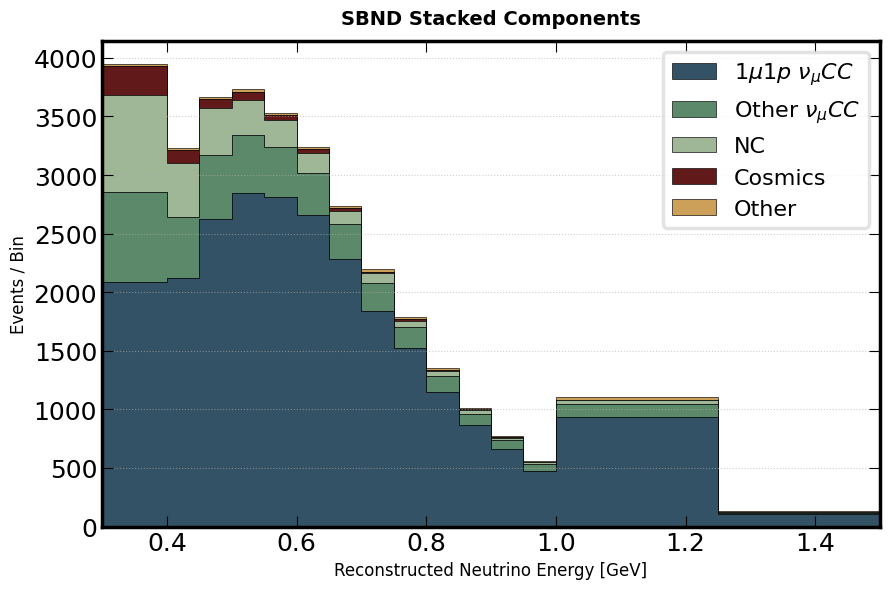

In [20]:
def plot_stacked_ic_run_with_offbeam(df, offbeam_df=None, scale_by_bin_width=True):
    """
    Plots a stacked histogram using the classification breakdown defined in gump_cuts.py.
    Combines off-beam and normal dataframes up front to simplify data processing.
    """
    # 1. Combine Dataframes Up Front (if off-beam data is provided)
    if offbeam_df is not None and not offbeam_df.empty:
        # Create a copy to protect the original dataframe from modifications
        offbeam_copy = offbeam_df.copy()
        offbeam_copy['true_is_cosmic'] = True
        
        # Combine them; sort=False keeps it fast if columns don't match perfectly
        df = pd.concat([df, offbeam_copy], ignore_index=True, sort=False)

    # 2. Define Binning & Apply Global Kinetic Kinematic Cuts
    bin_edges = np.array([0.3, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7, 0.75,
                          0.8, 0.85, 0.9, 0.95, 1.0, 1.25, 1.5])
    
    # Filter after combining so the cut applies uniformly to both sets of data
    df = df[df.del_p < 0.6].copy()

    labels = gc.get_top_labels()
    colors = ['#1e3f54', '#4a7c59', '#95af8b', '#500000', '#c89648']
    active_run = df['detector'].iloc[0] if 'detector' in df.columns else "ICARUS"

    # 3. Extract Unified Data Breakdown
    # Because we consolidated up front, gc.breakdown_top processes everything together natively
    plot_data = [x.values for x in gc.breakdown_top(df['nu_E_calo'], df)]
    plot_weights = [x.values for x in gc.breakdown_top(df['glob_scale'], df)]

    # 4. Apply Optional Bin Width Scaling
    if scale_by_bin_width:
        bin_widths = np.diff(bin_edges)
        scaled_weights = []
        
        for data, weights in zip(plot_data, plot_weights):
            if len(data) == 0:
                scaled_weights.append(weights)
                continue
            
            # Find matching bins and bound them to valid array indices
            bin_indices = np.digitize(data, bin_edges) - 1
            bin_indices = np.clip(bin_indices, 0, len(bin_widths) - 1)
            
            event_widths = bin_widths[bin_indices]
            scaled_weights.append(weights / event_widths)
            
        plot_weights = scaled_weights

    # 5. Generate the Stacked Histogram
    plt.figure(figsize=(9, 6))

    plt.hist(
        plot_data,
        bins=bin_edges,
        weights=plot_weights,
        stacked=True,
        color=colors,
        label=labels,
        histtype='stepfilled',
        edgecolor='black',
        linewidth=0.5,
        alpha=0.9
    )

    # 6. Presentation Refinements
    plt.xlim(bin_edges[0], bin_edges[-1])
    plt.xlabel("Reconstructed Neutrino Energy [GeV]", fontsize=12)
    plt.ylabel("Events / GeV" if scale_by_bin_width else "Events / Bin", fontsize=12)
    plt.title(f"{active_run} Stacked Components", fontsize=14, weight='bold', pad=12)

    # Reverse legend to match visual top-to-bottom stack sequence
    handles, labels_legend = plt.gca().get_legend_handles_labels()
    plt.legend(handles[::-1], labels_legend[::-1], loc='upper right', frameon=True, edgecolor='gainsboro')

    plt.grid(axis='y', linestyle=':', alpha=0.6)
    plt.tight_layout()
    plt.show()

# --- Execution ---
# Call it in your cell passing both dataframes
if DETECTOR == "ICARUS Run2":
    OFFdf['glob_scale'] = 2e20/OFFpot # these magic numbers are based off the xml scaling detector pot/file pot
    df['glob_scale'] *= 2e20/POT
elif DETECTOR == "ICARUS Run4":
    OFFdf['glob_scale'] = 3e20/OFFpot
    df['glob_scale'] *= 3e20/POT
elif DETECTOR == "SBND":
    OFFdf['glob_scale'] = 1e20/OFFpot
    df['glob_scale'] *= 1e20/POT

plot_stacked_ic_run_with_offbeam(df.loc[df["PID Cut"]], OFFdf.loc[OFFdf["PID Cut"]], scale_by_bin_width=False)
if DETECTOR == "ICARUS Run2":
    df['glob_scale'] *= POT/2e20
elif DETECTOR == "ICARUS Run4":
    df['glob_scale'] *= POT/3e20
elif DETECTOR == "SBND":
    df['glob_scale'] *= POT/1e20